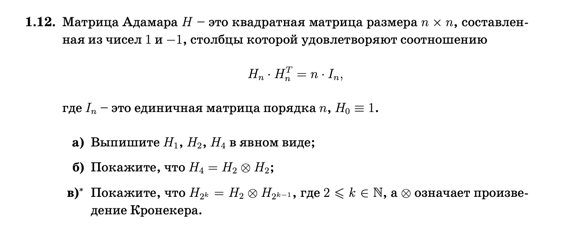

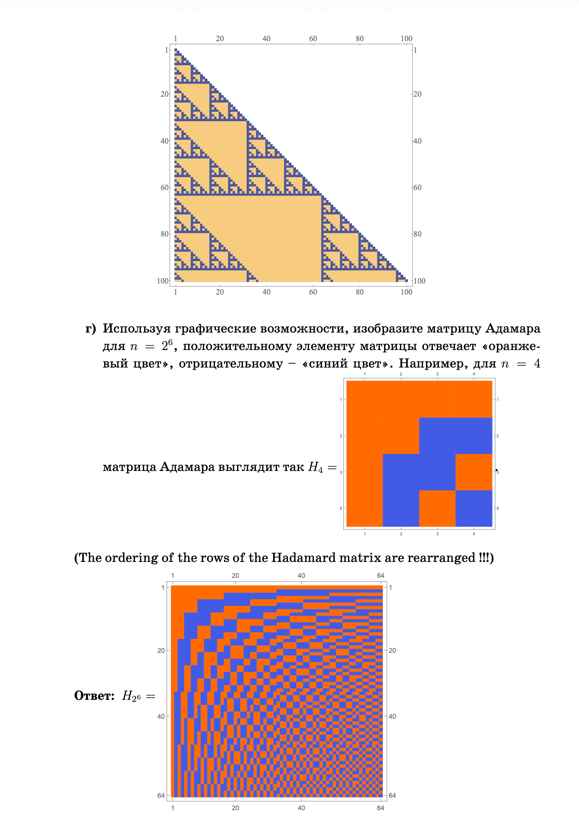
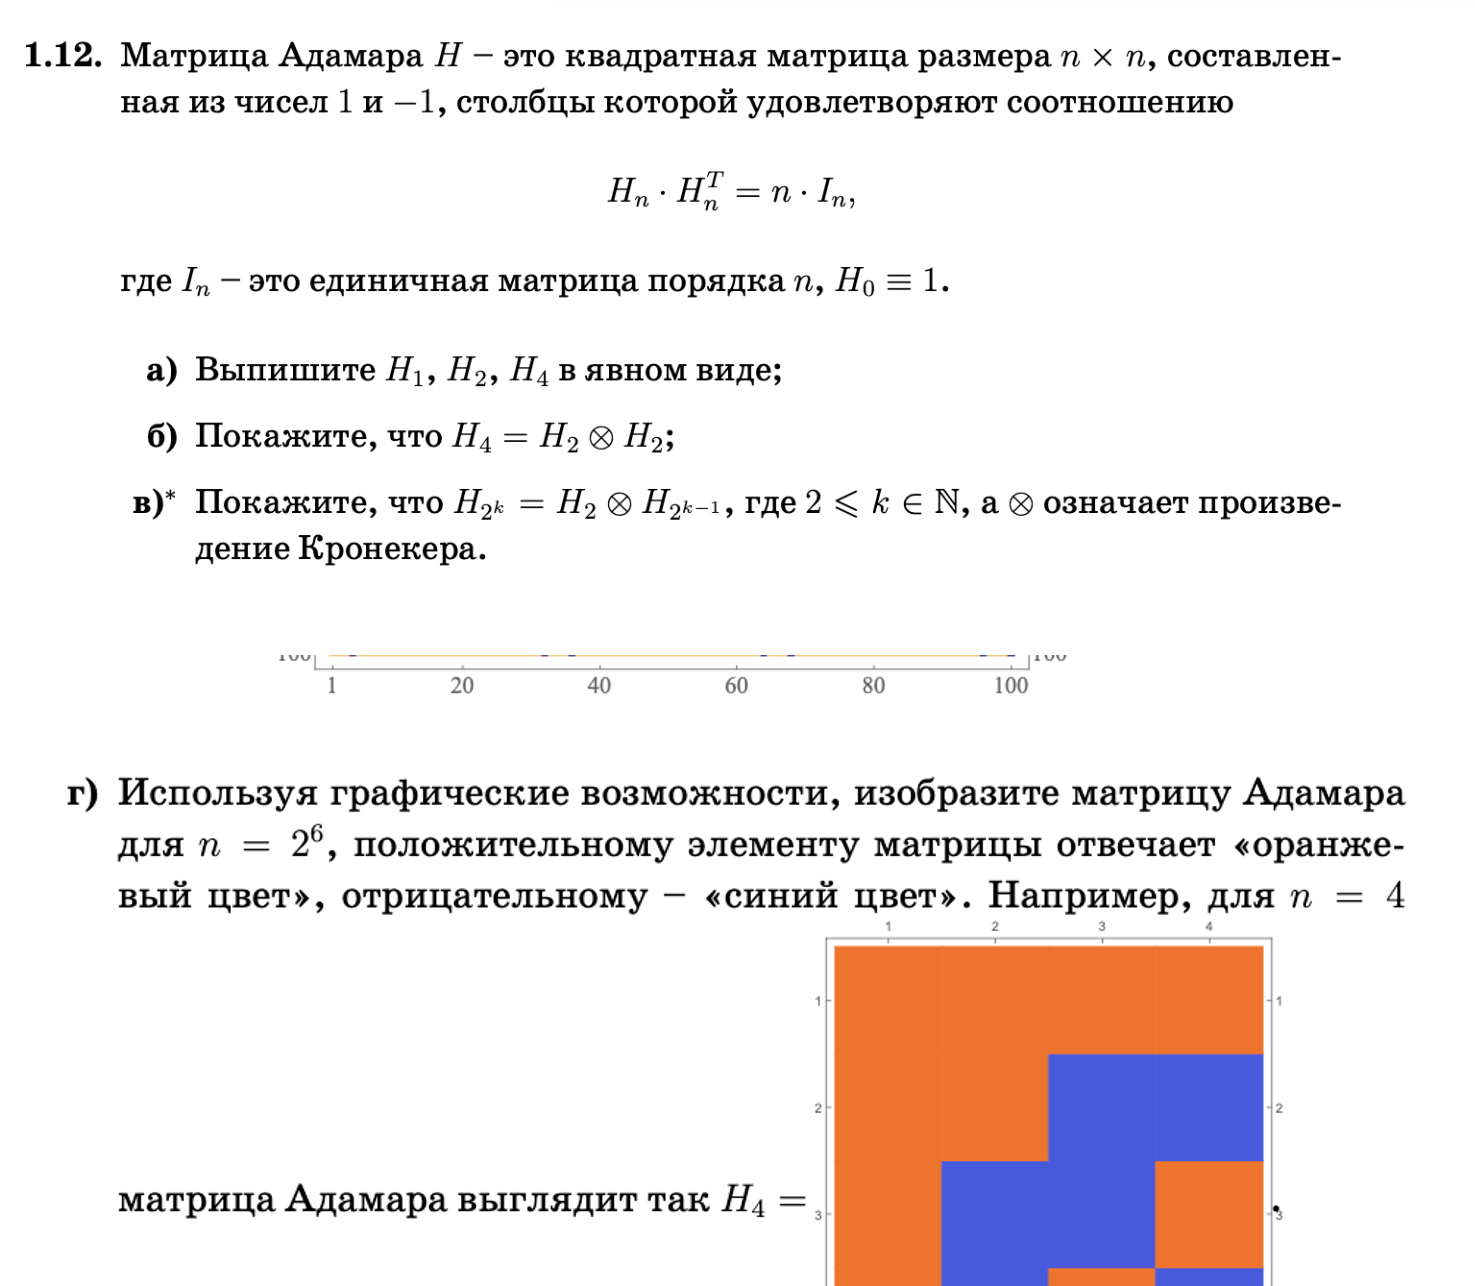


---

## Основные определения

### Матрица Адамара

**Матрица Адамара** $H_n$ — квадратная матрица размера $n\times n$, элементы которой равны только $1$ или $-1$, а строки и столбцы попарно ортогональны.

Для неё выполняется условие

$$
H_nH_n^T=nI_n,
$$

где $H_n^T$ — транспонированная матрица, а $I_n$ — единичная матрица порядка $n$.

Это равенство означает, что скалярное произведение каждой строки самой на себя равно $n$, а скалярное произведение любых двух различных строк равно нулю.

### Транспонированная матрица

**Транспонирование** — операция, при которой строки матрицы становятся столбцами:

$$
(A^T)_{ij}=A_{ji}.
$$

Например,

$$
\begin{pmatrix}
a&b\\
c&d
\end{pmatrix}^T
=
\begin{pmatrix}
a&c\\
b&d
\end{pmatrix}.
$$

### Единичная матрица

**Единичная матрица** $I_n$ — квадратная матрица, у которой на главной диагонали стоят единицы, а остальные элементы равны нулю:

$$
I_2=
\begin{pmatrix}
1&0\\
0&1
\end{pmatrix}.
$$

### Ортогональность

Два вектора называются **ортогональными**, если их скалярное произведение равно нулю.

Например, строки $(1,1)$ и $(1,-1)$ ортогональны:

$$
(1,1)\cdot(1,-1)=1\cdot1+1\cdot(-1)=0.
$$

### Произведение Кронекера

**Произведение Кронекера** $A\otimes B$ строится заменой каждого элемента матрицы $A$ на блок, равный этому элементу, умноженному на всю матрицу $B$.

Если

$$
A=
\begin{pmatrix}
a&b\\
c&d
\end{pmatrix},
$$

то

$$
A\otimes B=
\begin{pmatrix}
aB&bB\\
cB&dB
\end{pmatrix}.
$$

---

## Необходимые формулы

### 1. Условие матрицы Адамара

$$
H_nH_n^T=nI_n.
$$

### 2. Начальные матрицы

Для построения матриц Адамара Сильвестра начинаем с

$$
H_1=(1),
$$

$$
H_2=
\begin{pmatrix}
1&1\\
1&-1
\end{pmatrix}.
$$

### 3. Рекуррентное построение — конструкция Сильвестра

Следующая матрица строится из предыдущей по правилу

$$
H_{2n}=
\begin{pmatrix}
H_n&H_n\\
H_n&-H_n
\end{pmatrix}.
$$

То же самое можно записать через произведение Кронекера:

$$
H_{2n}=H_2\otimes H_n.
$$

---

## Алгоритм решения

### Шаг 1: Выписываем $H_1$, $H_2$ и $H_4$

Имеем

$$
H_1=(1),
$$

$$
H_2=
\begin{pmatrix}
1&1\\
1&-1
\end{pmatrix}.
$$

Для $H_4$ используем рекуррентное построение:

$$
H_4=
\begin{pmatrix}
H_2&H_2\\
H_2&-H_2
\end{pmatrix}
=
\begin{pmatrix}
1&1&1&1\\
1&-1&1&-1\\
1&1&-1&-1\\
1&-1&-1&1
\end{pmatrix}.
$$

### Шаг 2: Показываем, что $H_4=H_2\otimes H_2$

По определению произведения Кронекера

$$
H_2\otimes H_2=
\begin{pmatrix}
1\cdot H_2&1\cdot H_2\\
1\cdot H_2&(-1)\cdot H_2
\end{pmatrix}
=
\begin{pmatrix}
H_2&H_2\\
H_2&-H_2
\end{pmatrix}.
$$

После раскрытия блоков получаем ровно матрицу $H_4$. Следовательно,

$$
\boxed{H_4=H_2\otimes H_2}.
$$

В программе произведение Кронекера вычисляется функцией `np.kron`.

### Шаг 3: Получаем общую рекуррентную формулу

Для матрицы порядка $2^k$ предыдущая матрица имеет порядок $2^{k-1}$. Поэтому

$$
H_{2^k}=
\begin{pmatrix}
H_{2^{k-1}}&H_{2^{k-1}}\\
H_{2^{k-1}}&-H_{2^{k-1}}
\end{pmatrix}.
$$

С другой стороны,

$$
H_2\otimes H_{2^{k-1}}
=
\begin{pmatrix}
1\cdot H_{2^{k-1}}&1\cdot H_{2^{k-1}}\\
1\cdot H_{2^{k-1}}&(-1)\cdot H_{2^{k-1}}
\end{pmatrix}.
$$

Правые части совпадают, поэтому

$$
\boxed{H_{2^k}=H_2\otimes H_{2^{k-1}}}.
$$

### Шаг 4: Строим $H_{2^6}=H_{64}$

Так как $2^6=64$, последовательно применяем рекуррентную формулу:

$$
H_1\rightarrow H_2\rightarrow H_4\rightarrow H_8\rightarrow H_{16}\rightarrow H_{32}\rightarrow H_{64}.
$$

В программе это удобно выполнить циклом: начинаем с $H_1$ и шесть раз применяем `np.kron(H2, H)`.

### Шаг 5: Проверяем полученную матрицу

Для $H_{64}$ должно выполняться определение матрицы Адамара:

$$
H_{64}H_{64}^T=64I_{64}.
$$

В NumPy оператор `@` выполняет матричное умножение, `.T` транспонирует матрицу, а `np.eye(64)` создаёт единичную матрицу $64\times64$.

### Шаг 6: Строим изображение матрицы $H_{64}$ в порядке Сильвестра

В этой работе используем **конструкцию Сильвестра**.

Конструкция Сильвестра — это рекуррентный способ построения матриц Адамара порядков

$$
1,\;2,\;4,\;8,\;16,\ldots,\;2^k.
$$

Начинаем с

$$
H_1=(1),
$$

а каждую следующую матрицу строим по формуле

$$
H_{2n}=
\begin{pmatrix}
H_n&H_n\\
H_n&-H_n
\end{pmatrix}.
$$

Эквивалентно,

$$
H_{2n}=H_2\otimes H_n,
$$

где

$$
H_2=
\begin{pmatrix}
1&1\\
1&-1
\end{pmatrix}.
$$

Такой способ называется **конструкцией Сильвестра**, а полученные матрицы — **матрицами Адамара Сильвестра**.

Для $n=2^6=64$ получаем стандартную матрицу $H_{64}$ в порядке Сильвестра. В условии приведён рисунок с переставленными строками, поэтому визуально он может отличаться. Это не ошибка: перестановка строк сохраняет свойство матрицы Адамара.

В нашей работе строки не переставляем, потому что используем именно стандартное рекуррентное построение Сильвестра.

Для изображения:

- $-1$ обозначаем синим цветом;
- $1$ обозначаем оранжевым цветом.

Для визуализации используем `plt.imshow`.


ОТВЕТ А)
Матрицы H1, H2 и H4:

H1 =
[[1]]

H2 =
[[ 1  1]
 [ 1 -1]]

H4 =
[[ 1  1  1  1]
 [ 1 -1  1 -1]
 [ 1  1 -1 -1]
 [ 1 -1 -1  1]]

ОТВЕТ Б)
Проверяем равенство H4 = H2 ⊗ H2

H2 ⊗ H2 =
[[ 1  1  1  1]
 [ 1 -1  1 -1]
 [ 1  1 -1 -1]
 [ 1 -1 -1  1]]

H4 = H2 ⊗ H2: True

ОТВЕТ В)
Используем конструкцию Сильвестра:
H_(2^k) = H2 ⊗ H_(2^(k-1))

k = 2: H_4 = H2 ⊗ H_2 -> True
k = 3: H_8 = H2 ⊗ H_4 -> True
k = 4: H_16 = H2 ⊗ H_8 -> True
k = 5: H_32 = H2 ⊗ H_16 -> True
k = 6: H_64 = H2 ⊗ H_32 -> True

ОТВЕТ Г)
Строим H_(2^6) = H64 по конструкции Сильвестра.

Размер H64: (64, 64)
Проверка H64 @ H64.T = 64 * I64: True


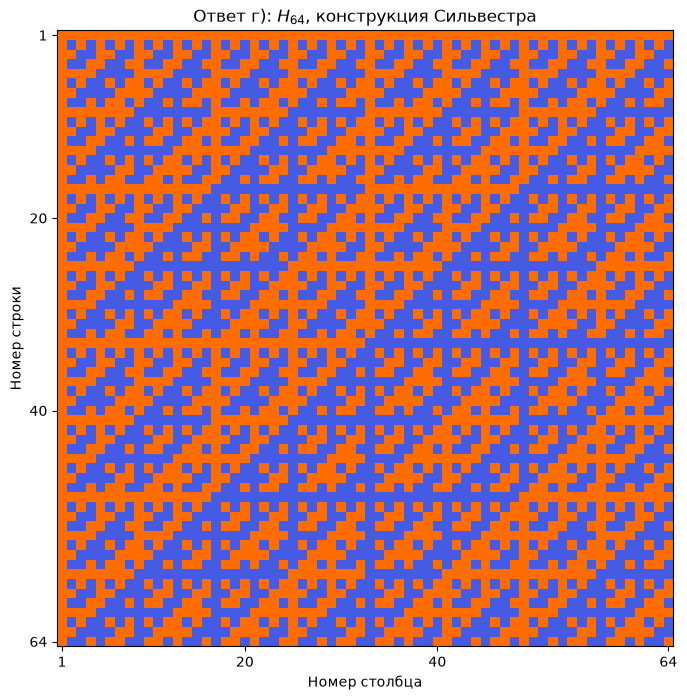

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


# ============================================================
# ПУНКТ А
# Нужно выписать H1, H2 и H4 в явном виде
# ============================================================

print("ОТВЕТ А)")
print("Матрицы H1, H2 и H4:\n")

# H1 — самая маленькая матрица Адамара.
# Она состоит только из одного элемента 1.
H1 = np.array([[1]])

# H2 — матрица Адамара второго порядка.
# Её элементы равны только 1 и -1.
H2 = np.array([
    [1,  1],
    [1, -1]
])

# H4 — матрица Адамара четвёртого порядка.
# Здесь мы сразу записываем её в явном виде.
# Она построена по конструкции Сильвестра:
# H4 = [[H2,  H2],
#       [H2, -H2]]
H4 = np.array([
    [1,  1,  1,  1],
    [1, -1,  1, -1],
    [1,  1, -1, -1],
    [1, -1, -1,  1]
])

# Выводим все три матрицы, чтобы получить ответ на пункт (а).
print("H1 =")
print(H1)

print("\nH2 =")
print(H2)

print("\nH4 =")
print(H4)


# ============================================================
# ПУНКТ Б
# Нужно показать, что H4 = H2 ⊗ H2
# ============================================================

print("\n" + "=" * 60)
print("ОТВЕТ Б)")
print("Проверяем равенство H4 = H2 ⊗ H2\n")

# np.kron(H2, H2) вычисляет произведение Кронекера H2 ⊗ H2.
#
# Смысл произведения Кронекера здесь такой:
# каждый элемент первой H2 заменяется целым блоком H2,
# умноженным на этот элемент.
#
# То есть:
#
# H2 ⊗ H2 = [[ 1*H2,  1*H2],
#             [ 1*H2, -1*H2]]
#
# Это как раз и даёт матрицу H4.
H4_kron = np.kron(H2, H2)

print("H2 ⊗ H2 =")
print(H4_kron)

# Сравниваем матрицу, полученную через произведение Кронекера,
# с H4, которую мы записали выше вручную.
#
# np.array_equal(A, B) возвращает True,
# если матрицы A и B полностью совпадают.
print("\nH4 = H2 ⊗ H2:", np.array_equal(H4, H4_kron))


# ============================================================
# ПУНКТ В
# Нужно показать общую формулу:
# H_(2^k) = H2 ⊗ H_(2^(k-1))
# ============================================================

print("\n" + "=" * 60)
print("ОТВЕТ В)")
print("Используем конструкцию Сильвестра:")
print("H_(2^k) = H2 ⊗ H_(2^(k-1))\n")


def hadamard_sylvester(k):
    """
    Строит матрицу Адамара Сильвестра H_(2^k).

    Например:
    k = 0 -> H1
    k = 1 -> H2
    k = 2 -> H4
    k = 3 -> H8
    и т.д.
    """

    # Начинаем с H1.
    # Это базовая матрица для рекуррентного построения.
    H = H1.copy()

    # Каждый раз применяем произведение Кронекера H2 ⊗ H.
    #
    # После одного шага:
    # H1 -> H2
    #
    # После двух шагов:
    # H2 -> H4
    #
    # После трёх:
    # H4 -> H8
    #
    # Поэтому после k шагов получаем H_(2^k).
    for _ in range(k):
        H = np.kron(H2, H)

    return H


# Математическое доказательство формулы находится в теоретической части.
# Здесь мы дополнительно проверяем её программно для нескольких k.
#
# Для каждого k:
# left  = H_(2^k)
# right = H2 ⊗ H_(2^(k-1))
#
# Если формула верна, np.array_equal вернёт True.
for k in range(2, 7):
    left = hadamard_sylvester(k)
    right = np.kron(H2, hadamard_sylvester(k - 1))

    print(
        f"k = {k}: "
        f"H_{2**k} = H2 ⊗ H_{2**(k-1)} -> "
        f"{np.array_equal(left, right)}"
    )


# ============================================================
# ПУНКТ Г
# Нужно построить и изобразить матрицу Адамара
# для n = 2^6 = 64
# ============================================================

print("\n" + "=" * 60)
print("ОТВЕТ Г)")
print("Строим H_(2^6) = H64 по конструкции Сильвестра.\n")

# Так как 2^6 = 64, передаём в функцию k = 6.
# В результате получаем матрицу размера 64 x 64.
H64 = hadamard_sylvester(6)

# .shape показывает размер матрицы.
# Ожидаем получить (64, 64).
print("Размер H64:", H64.shape)


# ------------------------------------------------------------
# Проверяем, что построенная H64 действительно является
# матрицей Адамара.
# ------------------------------------------------------------

# По определению для матрицы Адамара должно выполняться:
#
# H64 * H64^T = 64 * I64
#
# где:
# H64.T — транспонированная матрица,
# @      — матричное умножение,
# I64    — единичная матрица размера 64 x 64.

# Создаём единичную матрицу I64.
I64 = np.eye(64, dtype=int)

# Слева вычисляем H64 @ H64.T,
# справа — 64 * I64.
#
# Если обе матрицы совпадают, значит условие Адамара выполнено.
check = np.array_equal(
    H64 @ H64.T,
    64 * I64
)

print("Проверка H64 @ H64.T = 64 * I64:", check)


# ------------------------------------------------------------
# Теперь изображаем H64 цветами.
# ------------------------------------------------------------

# В условии сказано:
# +1 должен быть оранжевым,
# -1 должен быть синим.
#
# ListedColormap создаёт цветовую карту из двух цветов.
# Первый цвет соответствует меньшему значению (-1),
# второй — большему значению (+1).
cmap = ListedColormap(["#455BE3", "#FF6D00"])

# Создаём область для рисунка размером 8 x 8 дюймов.
plt.figure(figsize=(8, 8))

# imshow отображает матрицу как картинку.
# Каждому элементу матрицы соответствует цветная клетка.
#
# vmin=-1 и vmax=1 задают диапазон значений.
# interpolation="nearest" нужен, чтобы клетки были чёткими,
# без размытия между соседними элементами.
# aspect="equal" делает клетки квадратными.
plt.imshow(
    H64,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    interpolation="nearest",
    aspect="equal"
)

# Подписываем рисунок и оси.
plt.title(r"Ответ г): $H_{64}$, конструкция Сильвестра")
plt.xlabel("Номер столбца")
plt.ylabel("Номер строки")

# В Python индексация начинается с 0,
# но на рисунке хотим показывать обычную нумерацию от 1 до 64.
#
# Поэтому позициям 0, 19, 39, 63
# ставим подписи 1, 20, 40, 64.
plt.xticks([0, 19, 39, 63], [1, 20, 40, 64])
plt.yticks([0, 19, 39, 63], [1, 20, 40, 64])

# Показываем готовое изображение матрицы H64.
plt.show()
